In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import sys
import importlib.util

sns.set(style="whitegrid", context="notebook")

# Import the function classes from generate_ihdp_data.py so pickle can find them
# This is needed because the pickle file references these classes
spec = importlib.util.spec_from_file_location("generate_ihdp_data", "generate_ihdp_data.py")
generate_ihdp = importlib.util.module_from_spec(spec)
sys.modules['generate_ihdp_data'] = generate_ihdp
spec.loader.exec_module(generate_ihdp)

# Also make them available in __main__ for pickle compatibility
from generate_ihdp_data import XIdentityFunction, TFunction, YFunction, IHDPNonlinearAddSCM
import __main__
__main__.XIdentityFunction = XIdentityFunction
__main__.TFunction = TFunction
__main__.YFunction = YFunction
__main__.IHDPNonlinearAddSCM = IHDPNonlinearAddSCM

# Load the generated IHDP models
data_dir = "data/ihdp_envcopies"

print("Loading IHDP models...")
LLmodel = joblib.load(f"{data_dir}/LLmodel.pkl")
HLmodel = joblib.load(f"{data_dir}/HLmodel.pkl")
abstraction_data = joblib.load(f"{data_dir}/abstraction_data.pkl")

print("✅ Data loaded successfully!")
print(f"\nLL model keys: {list(LLmodel.keys())}")
print(f"HL model keys: {list(HLmodel.keys())}")
print(f"Abstraction data keys: {list(abstraction_data.keys())}")


Loading IHDP models...
✅ Data loaded successfully!

LL model keys: ['graph', 'intervention_set', 'functions', 'noise_dist', 'data', 'scm_instances', 'noise', 'var_order']
HL model keys: ['graph', 'intervention_set', 'functions', 'noise_dist', 'data', 'scm_instances', 'noise', 'var_order']
Abstraction data keys: ['T', 'omega']


/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle

In [3]:
# Explore the structure
print("=== Model Structure ===")
print(f"\nVariable order: {LLmodel['var_order']}")
print(f"Number of variables: {len(LLmodel['var_order'])}")
print(f"\nAvailable interventions:")
for i, interv in enumerate(LLmodel['intervention_set']):
    if interv is None:
        print(f"  {i}: None (observational)")
    else:
        print(f"  {i}: {interv.vv()}")

print(f"\nNoise distribution:")
print(f"  Mean shape: {LLmodel['noise_dist']['mu'].shape}")
print(f"  Sigma shape: {LLmodel['noise_dist']['sigma'].shape}")
print(f"  Mean (first 5): {LLmodel['noise_dist']['mu'][:5]}")
print(f"  Sigma diagonal (first 5): {np.diag(LLmodel['noise_dist']['sigma'])[:5]}")


=== Model Structure ===

Variable order: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'T', 'Y']
Number of variables: 27

Available interventions:
  0: None (observational)
  1: {'T': 0.0}
  2: {'T': 1.0}

Noise distribution:
  Mean shape: (27,)
  Sigma shape: (27, 27)
  Mean (first 5): [ 1.07381009e-17 -2.91303498e-17  4.23579066e-17 -8.95312383e-16
 -4.22835944e-17]
  Sigma diagonal (first 5): [0.99866131 0.99866131 0.99866131 0.99866131 0.99866131]


In [4]:
# Extract observational data
iota0 = LLmodel['intervention_set'][0]  # Observational intervention (None)

# Get indices for key variables
var_order = LLmodel['var_order']
x_cols = [v for v in var_order if v.startswith('x')]
t_idx = var_order.index('T')
y_idx = var_order.index('Y')
x_indices = [var_order.index(x) for x in x_cols]

print(f"Variable indices:")
print(f"  X variables: {x_cols[:5]}... (indices {x_indices[:5]}...)")
print(f"  T index: {t_idx}")
print(f"  Y index: {y_idx}")

# Get observational data
obs_data = LLmodel['data'][iota0]
obs_noise = LLmodel['noise'][iota0]

print(f"\nObservational data shape: {obs_data.shape}")
print(f"Observational noise shape: {obs_noise.shape}")

# Extract key variables
X_obs = obs_data[:, x_indices]
T_obs = obs_data[:, t_idx]
Y_obs = obs_data[:, y_idx]

print(f"\nExtracted variables:")
print(f"  X shape: {X_obs.shape}")
print(f"  T shape: {T_obs.shape} (unique values: {np.unique(T_obs)})")
print(f"  Y shape: {Y_obs.shape}")
print(f"  Y range: [{Y_obs.min():.2f}, {Y_obs.max():.2f}]")


Variable indices:
  X variables: ['x1', 'x2', 'x3', 'x4', 'x5']... (indices [0, 1, 2, 3, 4]...)
  T index: 25
  Y index: 26

Observational data shape: (747, 27)
Observational noise shape: (747, 27)

Extracted variables:
  X shape: (747, 25)
  T shape: (747,) (unique values: [0. 1.])
  Y shape: (747,)
  Y range: [-1.54, 11.27]


/var/folders/vn/9swzhgj513q7n9gd_4vsbd840000gn/T/ipykernel_6485/2469251076.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([Y_obs[T_obs == 0], Y_obs[T_obs == 1]], labels=['T=0', 'T=1'])


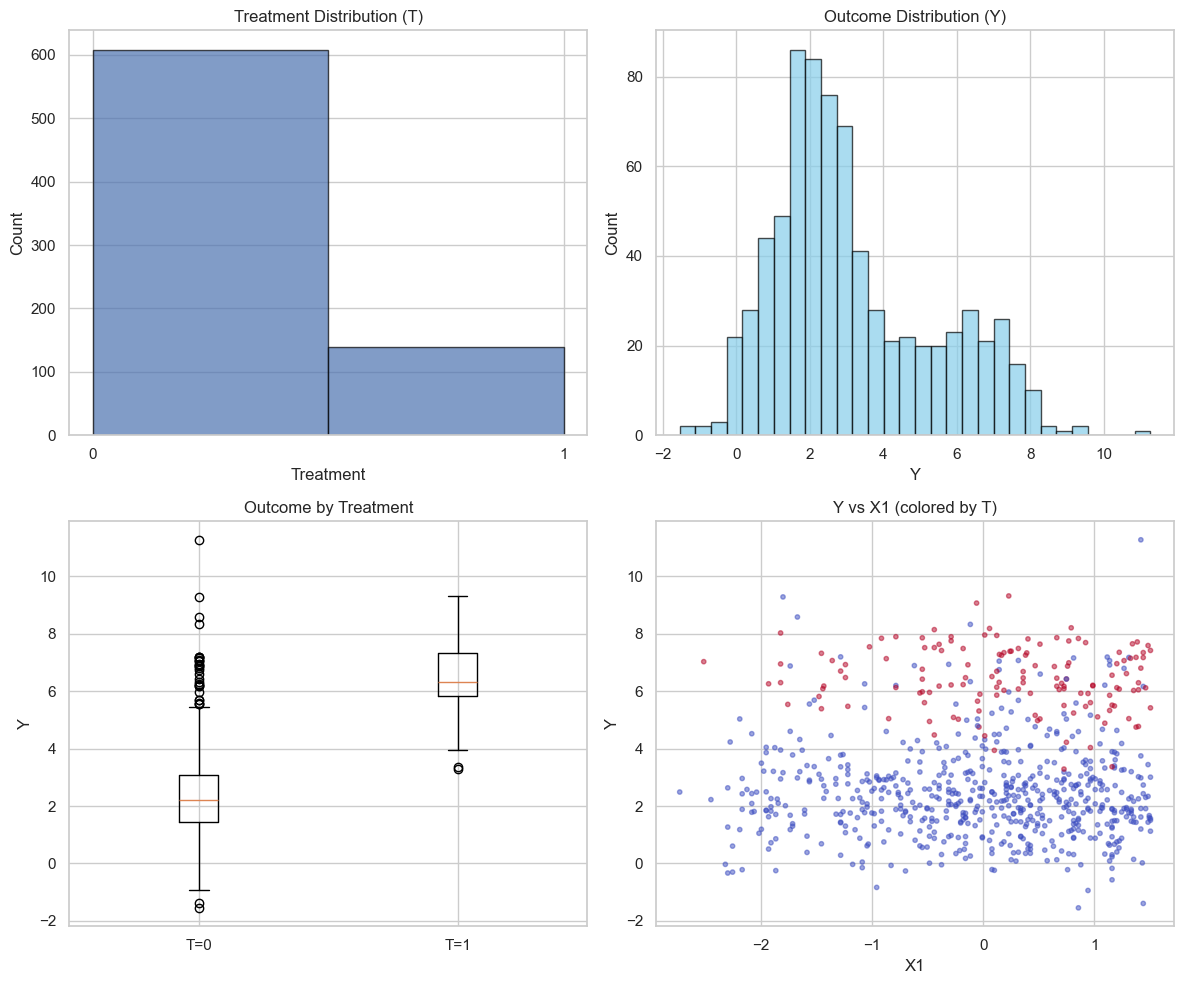

=== Summary Statistics ===
Treatment proportion: 0.186
Y mean (T=0): 2.411
Y mean (T=1): 6.432
Naive ATE: 4.021


In [5]:
# Visualize observational data
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Treatment distribution
axes[0, 0].hist(T_obs, bins=2, edgecolor='black', alpha=0.7)
axes[0, 0].set_title("Treatment Distribution (T)")
axes[0, 0].set_xlabel("Treatment")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_xticks([0, 1])

# Outcome distribution
axes[0, 1].hist(Y_obs, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 1].set_title("Outcome Distribution (Y)")
axes[0, 1].set_xlabel("Y")
axes[0, 1].set_ylabel("Count")

# Outcome by treatment
axes[1, 0].boxplot([Y_obs[T_obs == 0], Y_obs[T_obs == 1]], labels=['T=0', 'T=1'])
axes[1, 0].set_title("Outcome by Treatment")
axes[1, 0].set_ylabel("Y")

# Scatter: first covariate vs outcome
axes[1, 1].scatter(X_obs[:, 0], Y_obs, alpha=0.5, s=10, c=T_obs, cmap='coolwarm')
axes[1, 1].set_title("Y vs X1 (colored by T)")
axes[1, 1].set_xlabel("X1")
axes[1, 1].set_ylabel("Y")

plt.tight_layout()
plt.show()

# Summary statistics
print("=== Summary Statistics ===")
print(f"Treatment proportion: {T_obs.mean():.3f}")
print(f"Y mean (T=0): {Y_obs[T_obs == 0].mean():.3f}")
print(f"Y mean (T=1): {Y_obs[T_obs == 1].mean():.3f}")
print(f"Naive ATE: {Y_obs[T_obs == 1].mean() - Y_obs[T_obs == 0].mean():.3f}")


Graph nodes: ['x1', 'T', 'Y', 'x2', 'x3']... (showing first 5)
Total nodes: 27
Graph edges: [('x1', 'T'), ('x1', 'Y'), ('T', 'Y'), ('x2', 'T'), ('x2', 'Y'), ('x3', 'T'), ('x3', 'Y'), ('x4', 'T'), ('x4', 'Y'), ('x5', 'T')]... (showing first 10)
Total edges: 51


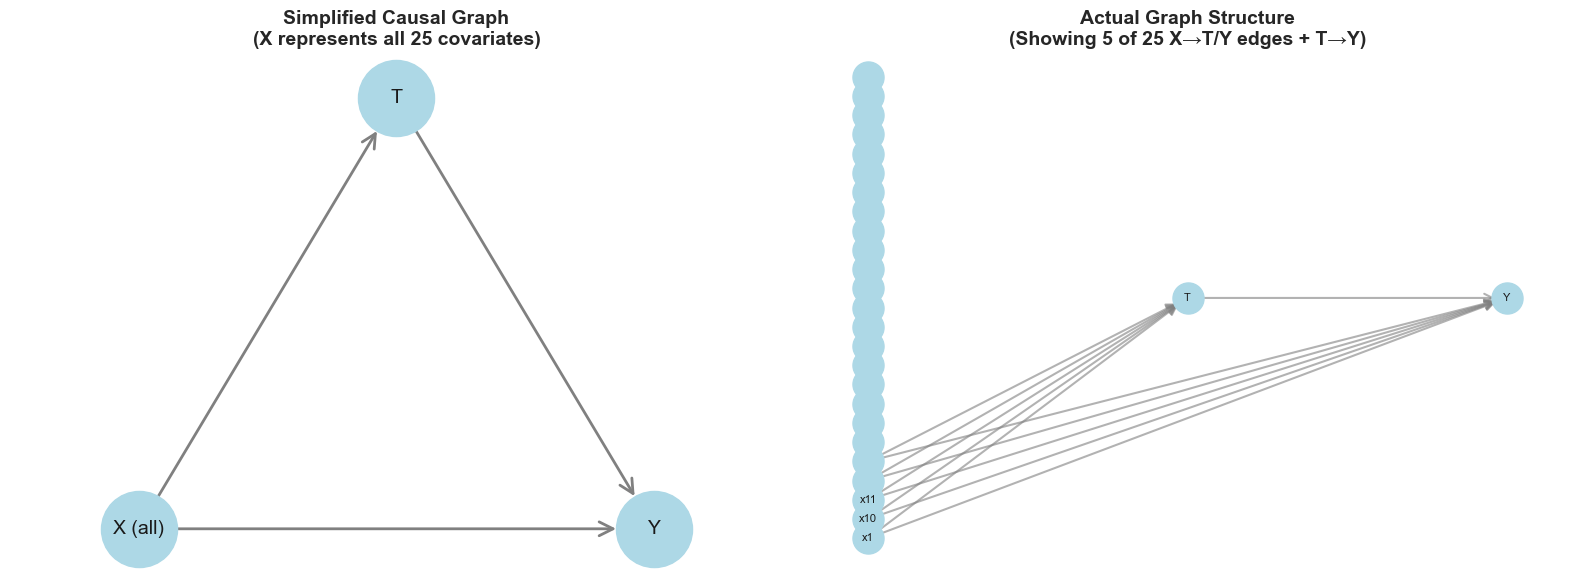


Graph structure:
  - 25 X variables (x1...x25)
  - 1 T variable (treatment)
  - 1 Y variable (outcome)
  - Each X connects to both T and Y
  - T connects to Y


In [9]:
# Visualize causal graph
G = LLmodel['graph']

print(f"Graph nodes: {list(G.nodes())[:5]}... (showing first 5)")
print(f"Total nodes: {len(G.nodes())}")
print(f"Graph edges: {list(G.edges())[:10]}... (showing first 10)")
print(f"Total edges: {len(G.edges())}")

# Create a simplified visualization showing the structure
# Group X variables together for visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Simplified conceptual graph
G_simple = nx.DiGraph()
G_simple.add_edges_from([
    ("X (all)", "T"),
    ("X (all)", "Y"),
    ("T", "Y")
])

pos_simple = {
    "X (all)": (0, 0),
    "T": (1, 0.5),
    "Y": (2, 0)
}

nx.draw(G_simple, pos_simple, ax=axes[0], with_labels=True, arrows=True, 
        node_size=3000, node_color="lightblue", font_size=14, 
        arrowstyle="->", arrowsize=25, edge_color='gray', width=2)
axes[0].set_title("Simplified Causal Graph\n(X represents all 25 covariates)", 
                  fontsize=14, fontweight='bold')
axes[0].set_xlim(-0.5, 2.5)

# Right: Show actual graph structure (without drawing all edges)
# Create a hierarchical layout
x_nodes = [n for n in G.nodes() if n.startswith('x')]
t_node = 'T'
y_node = 'Y'

# Create a better layout
pos = {}
# X variables in a column on the left
for i, x in enumerate(sorted(x_nodes)):
    pos[x] = (0, i * 0.3)
# T in the middle
pos[t_node] = (1, len(x_nodes) * 0.3 / 2)
# Y on the right
pos[y_node] = (2, len(x_nodes) * 0.3 / 2)

# Draw only a subset of edges to avoid clutter
# Show edges from first few X to T and Y, plus T->Y
edges_to_show = []
for x in sorted(x_nodes)[:5]:  # Show first 5 X variables
    edges_to_show.append((x, t_node))
    edges_to_show.append((x, y_node))
edges_to_show.append((t_node, y_node))

# Draw nodes
nx.draw_networkx_nodes(G, pos, ax=axes[1], node_size=500, 
                       node_color="lightblue", nodelist=list(G.nodes()))
# Draw only subset of edges
nx.draw_networkx_edges(G, pos, ax=axes[1], edgelist=edges_to_show,
                       edge_color='gray', width=1.5, arrows=True, 
                       arrowstyle="->", arrowsize=15, alpha=0.6)
# Draw labels for key nodes only
key_nodes = sorted(x_nodes)[:3] + [t_node, y_node]
labels = {n: n for n in key_nodes}
nx.draw_networkx_labels(G, pos, ax=axes[1], labels=labels, font_size=8)

axes[1].set_title(f"Actual Graph Structure\n(Showing 5 of {len(x_nodes)} X→T/Y edges + T→Y)", 
                  fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nGraph structure:")
print(f"  - {len(x_nodes)} X variables (x1...x25)")
print(f"  - 1 T variable (treatment)")
print(f"  - 1 Y variable (outcome)")
print(f"  - Each X connects to both T and Y")
print(f"  - T connects to Y")


In [10]:
# Analyze interventional distributions
print("=== Interventional Distributions ===\n")

# Get all interventions
interventions = LLmodel['intervention_set']
scm_instances = LLmodel['scm_instances']

# Generate samples for each intervention
n_samples = 1000
np.random.seed(42)

for i, interv in enumerate(interventions):
    if interv is None:
        print(f"Intervention {i}: Observational (None)")
        # Use existing observational data
        data_interv = obs_data
        T_interv = T_obs
        Y_interv = Y_obs
    else:
        print(f"Intervention {i}: {interv.vv()}")
        # Simulate from SCM
        scm = scm_instances[interv]
        # Sample noise from empirical distribution
        noise = np.random.multivariate_normal(
            LLmodel['noise_dist']['mu'],
            LLmodel['noise_dist']['sigma'],
            size=n_samples
        )
        data_interv = scm.simulate(noise)
        T_interv = data_interv[:, t_idx]
        Y_interv = data_interv[:, y_idx]
    
    print(f"  T unique values: {np.unique(T_interv)}")
    print(f"  Y mean: {Y_interv.mean():.3f}, std: {Y_interv.std():.3f}")
    print(f"  Y range: [{Y_interv.min():.2f}, {Y_interv.max():.2f}]")
    print()


=== Interventional Distributions ===

Intervention 0: Observational (None)
  T unique values: [0. 1.]
  Y mean: 3.160, std: 2.178
  Y range: [-1.54, 11.27]

Intervention 1: {'T': 0.0}
  T unique values: [-1.33497043e+00 -1.11810149e+00 -1.00816682e+00 -9.81617150e-01
 -9.42903667e-01 -9.34978693e-01 -9.30693463e-01 -9.26265230e-01
 -9.12867355e-01 -8.92422392e-01 -8.92287588e-01 -8.75158554e-01
 -8.66106905e-01 -8.57831812e-01 -8.45375710e-01 -8.17437580e-01
 -8.09957216e-01 -8.07474663e-01 -8.06995438e-01 -7.97308990e-01
 -7.90426680e-01 -7.79215461e-01 -7.76585573e-01 -7.71199288e-01
 -7.66440915e-01 -7.62602111e-01 -7.38865938e-01 -7.37148204e-01
 -7.23713748e-01 -7.16870861e-01 -7.08579365e-01 -7.01769430e-01
 -6.83720999e-01 -6.70191467e-01 -6.59969790e-01 -6.59913962e-01
 -6.49419744e-01 -6.45676214e-01 -6.44944902e-01 -6.39749328e-01
 -6.39561007e-01 -6.33235010e-01 -6.21708621e-01 -6.19623552e-01
 -6.18213040e-01 -6.17270076e-01 -6.15327393e-01 -6.11583124e-01
 -6.05407301e-01 

/var/folders/vn/9swzhgj513q7n9gd_4vsbd840000gn/T/ipykernel_6485/770537647.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([Y_do0, Y_do1], labels=['do(T=0)', 'do(T=1)'])


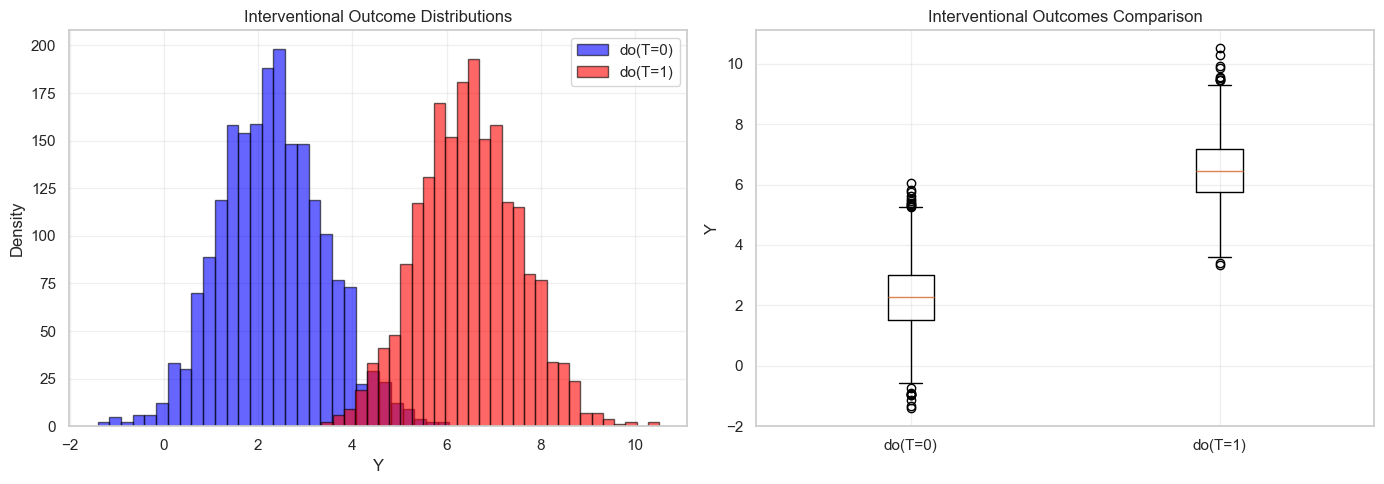

Average Treatment Effect (ATE): 4.169
  E[Y | do(T=1)]: 6.469
  E[Y | do(T=0)]: 2.300


In [11]:
# Compare interventional outcomes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simulate do(T=0) and do(T=1)
iota1 = interventions[1]  # do(T=0)
iota2 = interventions[2]  # do(T=1)

n_sim = 2000
np.random.seed(42)

# do(T=0)
scm_do0 = scm_instances[iota1]
noise_do0 = np.random.multivariate_normal(
    LLmodel['noise_dist']['mu'],
    LLmodel['noise_dist']['sigma'],
    size=n_sim
)
data_do0 = scm_do0.simulate(noise_do0)
Y_do0 = data_do0[:, y_idx]

# do(T=1)
scm_do1 = scm_instances[iota2]
noise_do1 = np.random.multivariate_normal(
    LLmodel['noise_dist']['mu'],
    LLmodel['noise_dist']['sigma'],
    size=n_sim
)
data_do1 = scm_do1.simulate(noise_do1)
Y_do1 = data_do1[:, y_idx]

# Plot distributions
axes[0].hist(Y_do0, bins=30, alpha=0.6, label='do(T=0)', color='blue', edgecolor='black')
axes[0].hist(Y_do1, bins=30, alpha=0.6, label='do(T=1)', color='red', edgecolor='black')
axes[0].set_title("Interventional Outcome Distributions")
axes[0].set_xlabel("Y")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot comparison
axes[1].boxplot([Y_do0, Y_do1], labels=['do(T=0)', 'do(T=1)'])
axes[1].set_title("Interventional Outcomes Comparison")
axes[1].set_ylabel("Y")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute Average Treatment Effect (ATE)
ate = Y_do1.mean() - Y_do0.mean()
print(f"Average Treatment Effect (ATE): {ate:.3f}")
print(f"  E[Y | do(T=1)]: {Y_do1.mean():.3f}")
print(f"  E[Y | do(T=0)]: {Y_do0.mean():.3f}")


=== Noise Analysis ===

Noise shape: (747, 27)
Variable order: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'T', 'Y']


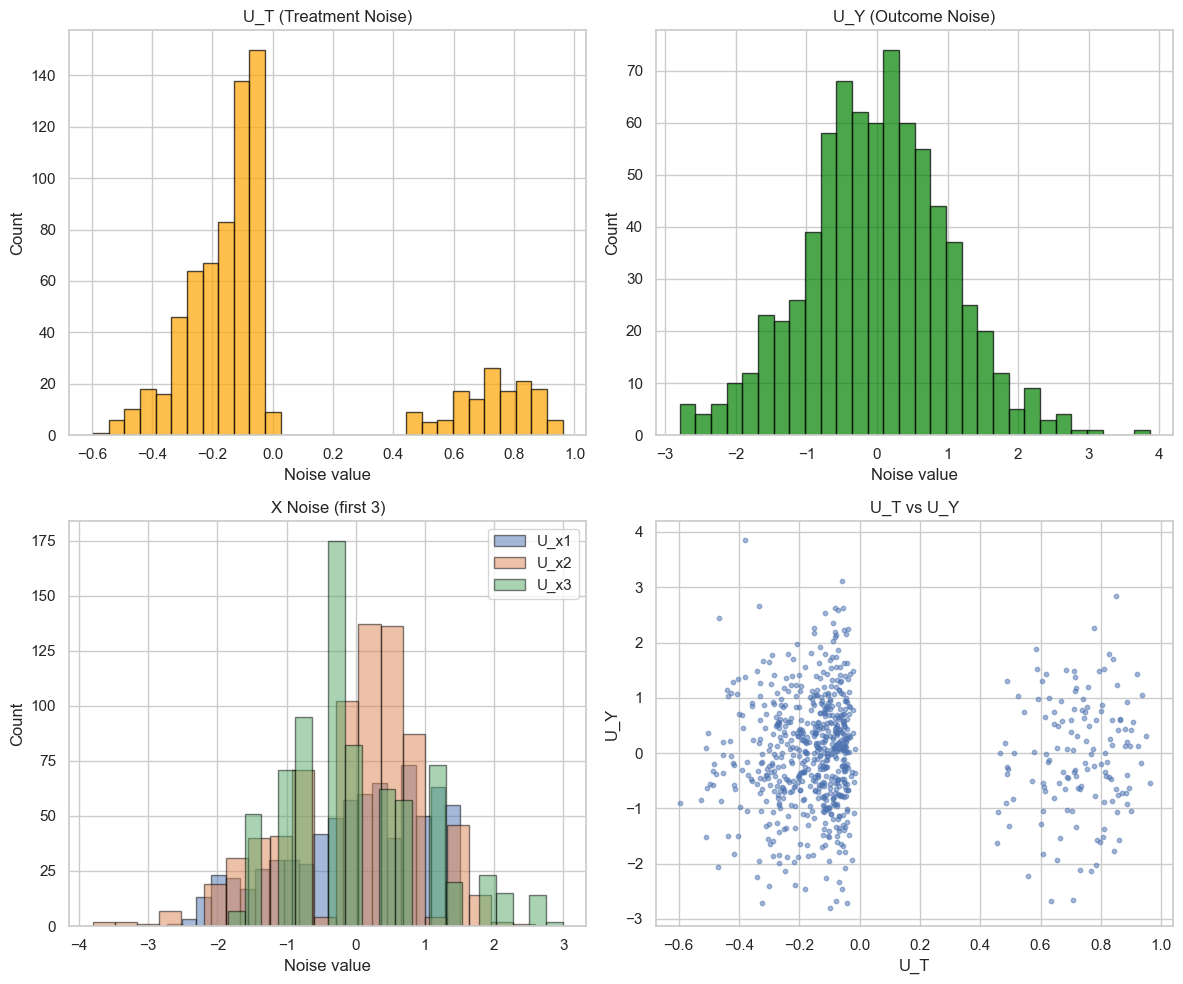


Noise statistics:
  U_T: mean=0.000, std=0.367
  U_Y: mean=-0.006, std=1.009
  U_T vs U_Y correlation: -0.002


In [12]:
# Analyze noise distributions
print("=== Noise Analysis ===\n")

# Observational noise
U_obs = obs_noise

print(f"Noise shape: {U_obs.shape}")
print(f"Variable order: {var_order}")

# Plot noise distributions for key variables
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# T noise
axes[0, 0].hist(U_obs[:, t_idx], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 0].set_title(f"U_T (Treatment Noise)")
axes[0, 0].set_xlabel("Noise value")
axes[0, 0].set_ylabel("Count")

# Y noise
axes[0, 1].hist(U_obs[:, y_idx], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title(f"U_Y (Outcome Noise)")
axes[0, 1].set_xlabel("Noise value")
axes[0, 1].set_ylabel("Count")

# X noise (first few)
for i in range(min(3, len(x_indices))):
    axes[1, 0].hist(U_obs[:, x_indices[i]], bins=20, alpha=0.5, 
                    label=f'U_{x_cols[i]}', edgecolor='black')
axes[1, 0].set_title("X Noise (first 3)")
axes[1, 0].set_xlabel("Noise value")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend()

# Noise correlation (T vs Y)
axes[1, 1].scatter(U_obs[:, t_idx], U_obs[:, y_idx], alpha=0.5, s=10)
axes[1, 1].set_title("U_T vs U_Y")
axes[1, 1].set_xlabel("U_T")
axes[1, 1].set_ylabel("U_Y")

plt.tight_layout()
plt.show()

print(f"\nNoise statistics:")
print(f"  U_T: mean={U_obs[:, t_idx].mean():.3f}, std={U_obs[:, t_idx].std():.3f}")
print(f"  U_Y: mean={U_obs[:, y_idx].mean():.3f}, std={U_obs[:, y_idx].std():.3f}")
print(f"  U_T vs U_Y correlation: {np.corrcoef(U_obs[:, t_idx], U_obs[:, y_idx])[0,1]:.3f}")


In [14]:
# Check abstraction data
print("=== Abstraction Data ===\n")

T_mat = abstraction_data['T']
omega = abstraction_data['omega']

print(f"Abstraction matrix T shape: {T_mat.shape}")
print(f"T is identity: {np.allclose(T_mat, np.eye(T_mat.shape[0]))}")

print(f"\nOmega mapping (intervention abstraction):")
for ll_interv, hl_interv in omega.items():
    if ll_interv is None:
        ll_str = "None (obs)"
    else:
        ll_str = str(ll_interv.vv())
    if hl_interv is None:
        hl_str = "None (obs)"
    else:
        hl_str = str(hl_interv.vv())
    print(f"  LL: {ll_str} -> HL: {hl_str}")

# Verify LL and HL are identical
print(f"\n=== LL vs HL Comparison ===")

# Compare graphs structurally (not by object identity)
G_LL = LLmodel['graph']
G_HL = HLmodel['graph']
same_nodes = set(G_LL.nodes()) == set(G_HL.nodes())
same_edges = set(G_LL.edges()) == set(G_HL.edges())
same_graph_structure = same_nodes and same_edges
same_graph_object = G_LL is G_HL  # Check if it's the same object

print(f"Same graph object (is): {same_graph_object}")
print(f"Same graph structure (nodes & edges): {same_graph_structure}")
if same_graph_structure:
    print(f"  - Nodes match: {same_nodes}")
    print(f"  - Edges match: {same_edges}")
    print(f"  - LL nodes: {len(G_LL.nodes())}, HL nodes: {len(G_HL.nodes())}")
    print(f"  - LL edges: {len(G_LL.edges())}, HL edges: {len(G_HL.edges())}")
else:
    print(f"  - LL nodes: {set(G_LL.nodes())}")
    print(f"  - HL nodes: {set(G_HL.nodes())}")
    print(f"  - LL edges (first 5): {list(G_LL.edges())[:5]}")
    print(f"  - HL edges (first 5): {list(G_HL.edges())[:5]}")

print(f"\nSame var_order: {LLmodel['var_order'] == HLmodel['var_order']}")
print(f"Same noise_dist mean: {np.allclose(LLmodel['noise_dist']['mu'], HLmodel['noise_dist']['mu'])}")
print(f"Same noise_dist sigma: {np.allclose(LLmodel['noise_dist']['sigma'], HLmodel['noise_dist']['sigma'])}")
print(f"Same observational data: {np.allclose(LLmodel['data'][iota0], HLmodel['data'][iota0])}")

# Check if functions are the same
same_functions = LLmodel['functions'] is HLmodel['functions']
print(f"Same functions object: {same_functions}")

print(f"\n✅ Conclusion: LL and HL models are {'IDENTICAL' if same_graph_structure and same_graph_object else 'STRUCTURALLY IDENTICAL (different objects)' if same_graph_structure else 'DIFFERENT'}")


=== Abstraction Data ===

Abstraction matrix T shape: (27, 27)
T is identity: True

Omega mapping (intervention abstraction):
  LL: None (obs) -> HL: None (obs)
  LL: {'T': 0.0} -> HL: {'T': 0.0}
  LL: {'T': 1.0} -> HL: {'T': 1.0}

=== LL vs HL Comparison ===
Same graph object (is): False
Same graph structure (nodes & edges): True
  - Nodes match: True
  - Edges match: True
  - LL nodes: 27, HL nodes: 27
  - LL edges: 51, HL edges: 51

Same var_order: True
Same noise_dist mean: True
Same noise_dist sigma: True
Same observational data: True
Same functions object: False

✅ Conclusion: LL and HL models are STRUCTURALLY IDENTICAL (different objects)


In [17]:
# Evaluate how well the fitted functions match the data
print("=== Function Fit Evaluation ===\n")

from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, log_loss

# Get the functions from the model
functions = LLmodel['functions']

# Extract observational data
iota0 = LLmodel['intervention_set'][0]
obs_data = LLmodel['data'][iota0]
obs_noise = LLmodel['noise'][iota0]

var_order = LLmodel['var_order']
x_cols = [v for v in var_order if v.startswith('x')]
t_idx = var_order.index('T')
y_idx = var_order.index('Y')
x_indices = [var_order.index(x) for x in x_cols]

X_obs = obs_data[:, x_indices]
T_obs = obs_data[:, t_idx]
Y_obs = obs_data[:, y_idx]

# Get the function objects
T_func = functions['T']
Y_func = functions['Y']

# ===== 1. Evaluate T function (treatment assignment) =====
print("1. Treatment Assignment Function (T = f_T(X) + U_T)")
print("-" * 60)

# Get parent values for T (all X variables)
parents_T = X_obs
u_T = obs_noise[:, t_idx]

# Predict T using the function
T_pred = T_func(parents_T, u_T)

# For logistic regression, the function returns probabilities
# Compare predicted probabilities with actual T
T_probs = T_func(parents_T, np.zeros_like(u_T))  # Without noise (just the deterministic part)

print(f"  Actual T values: {np.unique(T_obs)}")
print(f"  Predicted T probabilities (mean): {T_probs.mean():.3f}")
print(f"  Predicted T probabilities (std): {T_probs.std():.3f}")
print(f"  Predicted T probabilities range: [{T_probs.min():.3f}, {T_probs.max():.3f}]")

# Binarize predictions for accuracy
T_pred_binary = (T_probs > 0.5).astype(float)
accuracy = accuracy_score(T_obs, T_pred_binary)
log_loss_val = log_loss(T_obs, T_probs)

print(f"\n  Classification Metrics:")
print(f"    Accuracy: {accuracy:.3f}")
print(f"    Log Loss: {log_loss_val:.3f}")

# Check residuals (T - f_T(X))
T_residuals = T_obs - T_probs
print(f"\n  Residual Analysis:")
print(f"    Mean residual: {T_residuals.mean():.6f}")
print(f"    Std residual: {T_residuals.std():.3f}")
print(f"    Residual range: [{T_residuals.min():.3f}, {T_residuals.max():.3f}]")

# ===== 2. Evaluate Y function (outcome) =====
print("\n2. Outcome Function (Y = f_Y(X,T) + U_Y)")
print("-" * 60)

# Get parent values for Y ([T, x1, ..., x25])
parents_Y = np.column_stack([T_obs, X_obs])
u_Y = obs_noise[:, y_idx]

# Predict Y using the function (without noise for deterministic part)
Y_pred_det = Y_func(parents_Y, np.zeros_like(u_Y))  # Deterministic part
Y_pred_full = Y_func(parents_Y, u_Y)  # With noise

# Compare with actual Y
mse = mean_squared_error(Y_obs, Y_pred_full)
rmse = np.sqrt(mse)
r2 = r2_score(Y_obs, Y_pred_full)

print(f"  Actual Y range: [{Y_obs.min():.2f}, {Y_obs.max():.2f}]")
print(f"  Predicted Y range: [{Y_pred_full.min():.2f}, {Y_pred_full.max():.2f}]")
print(f"\n  Regression Metrics:")
print(f"    MSE: {mse:.3f}")
print(f"    RMSE: {rmse:.3f}")
print(f"    R²: {r2:.3f}")

# Residuals (comparing full prediction with noise)
Y_residuals_full = Y_obs - Y_pred_full
print(f"\n  Residual Analysis (with noise):")
print(f"    Mean residual: {Y_residuals_full.mean():.6f}")
print(f"    Std residual: {Y_residuals_full.std():.3f}")
print(f"    Residual range: [{Y_residuals_full.min():.3f}, {Y_residuals_full.max():.3f}]")
print(f"    Note: Should be ~0 since Y_obs = f_Y(X,T) + U_Y by construction")

# Residuals from deterministic prediction (this should match stored noise)
Y_residuals_det = Y_obs - Y_pred_det
print(f"\n  Residual Analysis (deterministic only):")
print(f"    Mean residual: {Y_residuals_det.mean():.6f}")
print(f"    Std residual: {Y_residuals_det.std():.3f}")
print(f"    Residual range: [{Y_residuals_det.min():.3f}, {Y_residuals_det.max():.3f}]")

# Check if residuals from deterministic prediction match the stored noise
print(f"\n  Noise Comparison (U_Y vs deterministic residuals):")
print(f"    Stored noise mean: {u_Y.mean():.6f}, Residual mean: {Y_residuals_det.mean():.6f}")
print(f"    Stored noise std: {u_Y.std():.3f}, Residual std: {Y_residuals_det.std():.3f}")
print(f"    Max absolute difference: {np.abs(u_Y - Y_residuals_det).max():.6f}")
print(f"    Are they equal? {np.allclose(u_Y, Y_residuals_det, atol=1e-5)}")
print(f"    ✅ This confirms: Y_obs = f_Y(X,T) + U_Y, where U_Y = Y_obs - f_Y(X,T)")

# ===== 3. Evaluate by treatment group =====
print("\n3. Outcome Function by Treatment Group")
print("-" * 60)

for t_val in [0, 1]:
    mask = T_obs == t_val
    if mask.sum() > 0:
        Y_t = Y_obs[mask]
        Y_pred_t_full = Y_pred_full[mask]
        Y_pred_t_det = Y_pred_det[mask]
        r2_t = r2_score(Y_t, Y_pred_t_full)
        mse_t = mean_squared_error(Y_t, Y_pred_t_full)
        print(f"  T={t_val} (n={mask.sum()}):")
        print(f"    MSE: {mse_t:.3f}, R²: {r2_t:.3f}")
        print(f"    Y mean: {Y_t.mean():.3f}, Y_pred (full) mean: {Y_pred_t_full.mean():.3f}")
        print(f"    Y_pred (det) mean: {Y_pred_t_det.mean():.3f}, Residual mean: {Y_residuals_det[mask].mean():.3f}")


=== Function Fit Evaluation ===

1. Treatment Assignment Function (T = f_T(X) + U_T)
------------------------------------------------------------
  Actual T values: [0. 1.]
  Predicted T probabilities (mean): 0.186
  Predicted T probabilities (std): 0.123
  Predicted T probabilities range: [0.015, 0.596]

  Classification Metrics:
    Accuracy: 0.819
    Log Loss: 0.423

  Residual Analysis:
    Mean residual: 0.000006
    Std residual: 0.367
    Residual range: [-0.596, 0.961]

2. Outcome Function (Y = f_Y(X,T) + U_Y)
------------------------------------------------------------
  Actual Y range: [-1.54, 11.27]
  Predicted Y range: [-1.54, 11.27]

  Regression Metrics:
    MSE: 0.000
    RMSE: 0.000
    R²: 1.000

  Residual Analysis (with noise):
    Mean residual: -0.000000
    Std residual: 0.000
    Residual range: [-0.000, 0.000]
    Note: Should be ~0 since Y_obs = f_Y(X,T) + U_Y by construction

  Residual Analysis (deterministic only):
    Mean residual: -0.005970
    Std resid

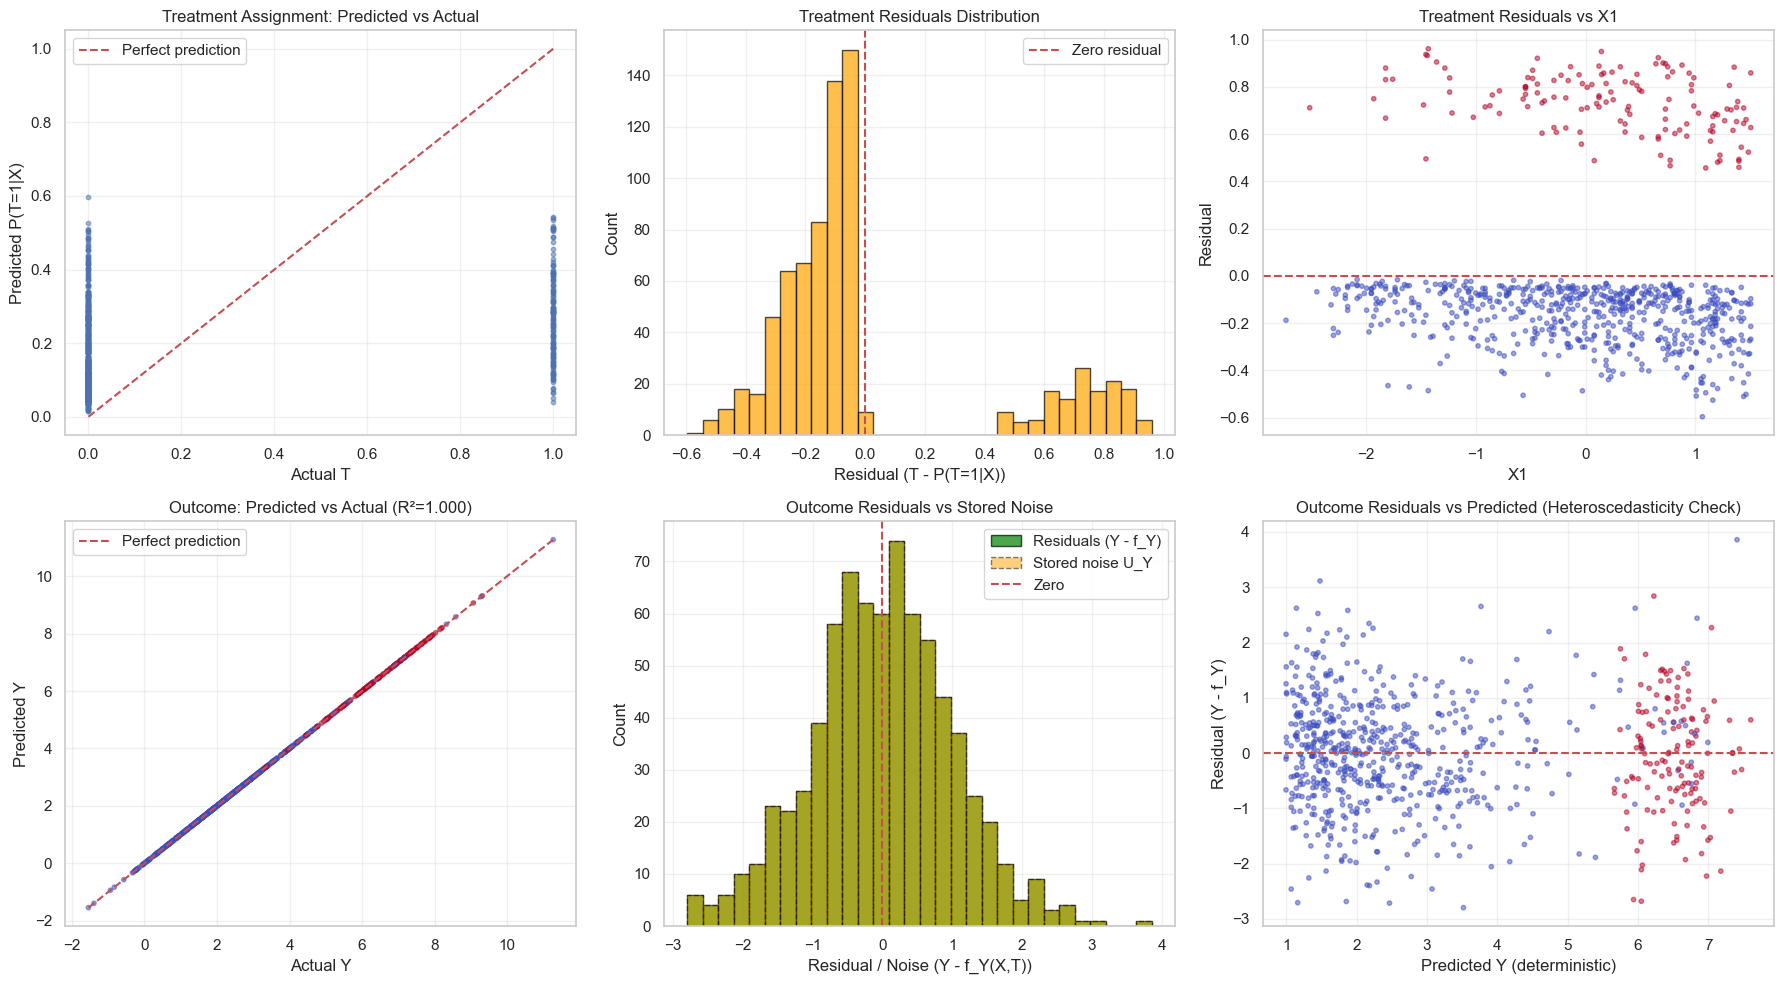


✅ Function fit evaluation complete!

Interpretation:
  - R² close to 1.0 indicates good fit
  - Residuals should be centered around 0
  - Residuals should be homoscedastic (constant variance)
  - For T: High accuracy and low log loss indicate good classification


In [18]:
# Visualize function fits
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Treatment function evaluation
# 1. Predicted vs Actual T probabilities
axes[0, 0].scatter(T_obs, T_probs, alpha=0.5, s=10)
axes[0, 0].plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
axes[0, 0].set_xlabel('Actual T')
axes[0, 0].set_ylabel('Predicted P(T=1|X)')
axes[0, 0].set_title('Treatment Assignment: Predicted vs Actual')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. T residuals distribution
axes[0, 1].hist(T_residuals, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].axvline(0, color='r', linestyle='--', label='Zero residual')
axes[0, 1].set_xlabel('Residual (T - P(T=1|X))')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Treatment Residuals Distribution')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. T residuals vs X1
axes[0, 2].scatter(X_obs[:, 0], T_residuals, alpha=0.5, s=10, c=T_obs, cmap='coolwarm')
axes[0, 2].axhline(0, color='r', linestyle='--')
axes[0, 2].set_xlabel('X1')
axes[0, 2].set_ylabel('Residual')
axes[0, 2].set_title('Treatment Residuals vs X1')
axes[0, 2].grid(True, alpha=0.3)

# Row 2: Outcome function evaluation
# 4. Predicted vs Actual Y
axes[1, 0].scatter(Y_obs, Y_pred_full, alpha=0.5, s=10, c=T_obs, cmap='coolwarm')
axes[1, 0].plot([Y_obs.min(), Y_obs.max()], [Y_obs.min(), Y_obs.max()], 'r--', label='Perfect prediction')
axes[1, 0].set_xlabel('Actual Y')
axes[1, 0].set_ylabel('Predicted Y')
axes[1, 0].set_title(f'Outcome: Predicted vs Actual (R²={r2:.3f})')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Y residuals distribution (deterministic - should match stored noise)
axes[1, 1].hist(Y_residuals_det, bins=30, edgecolor='black', alpha=0.7, color='green', label='Residuals (Y - f_Y)')
axes[1, 1].hist(u_Y, bins=30, edgecolor='black', alpha=0.5, color='orange', linestyle='--', label='Stored noise U_Y')
axes[1, 1].axvline(0, color='r', linestyle='--', label='Zero')
axes[1, 1].set_xlabel('Residual / Noise (Y - f_Y(X,T))')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Outcome Residuals vs Stored Noise')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Y residuals vs predicted Y (check for heteroscedasticity)
axes[1, 2].scatter(Y_pred_det, Y_residuals_det, alpha=0.5, s=10, c=T_obs, cmap='coolwarm')
axes[1, 2].axhline(0, color='r', linestyle='--')
axes[1, 2].set_xlabel('Predicted Y (deterministic)')
axes[1, 2].set_ylabel('Residual (Y - f_Y)')
axes[1, 2].set_title('Outcome Residuals vs Predicted (Heteroscedasticity Check)')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Function fit evaluation complete!")
print("\nInterpretation:")
print("  - R² close to 1.0 indicates good fit")
print("  - Residuals should be centered around 0")
print("  - Residuals should be homoscedastic (constant variance)")
print("  - For T: High accuracy and low log loss indicate good classification")


In [19]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

# Load original IHDP data (CEVAE format)
url = "https://raw.githubusercontent.com/AMLab-Amsterdam/CEVAE/master/datasets/IHDP/csv/ihdp_npci_1.csv"
raw = pd.read_csv(url, header=None)
cols = ["treatment", "y_factual", "y_cfactual", "mu0", "mu1"] + [f"x{i}" for i in range(1, 26)]
raw.columns = cols

T = raw["treatment"].values
Y = raw["y_factual"].values
mu0 = raw["mu0"].values
mu1 = raw["mu1"].values
X = raw[[f"x{i}" for i in range(1, 26)]].values


In [20]:
rf0 = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=0)
rf1 = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=1)

rf0.fit(X, mu0)
rf1.fit(X, mu1)

mu0_hat = rf0.predict(X)
mu1_hat = rf1.predict(X)

print("mu0 R^2:", r2_score(mu0, mu0_hat))
print("mu1 R^2:", r2_score(mu1, mu1_hat))
print("mu0 RMSE:", mean_squared_error(mu0, mu0_hat, squared=False))
print("mu1 RMSE:", mean_squared_error(mu1, mu1_hat, squared=False))


mu0 R^2: 0.9616921728320561
mu1 R^2: 0.9819623010028362


TypeError: got an unexpected keyword argument 'squared'

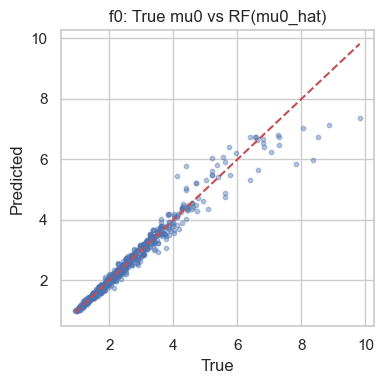

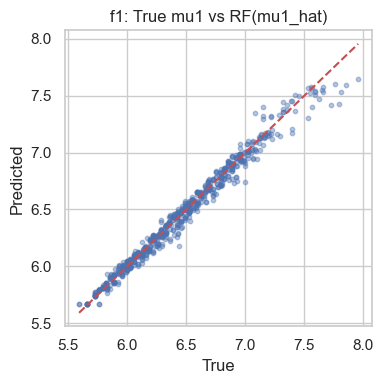

In [21]:
def diag_plot(true, pred, title):
    plt.figure(figsize=(4,4))
    plt.scatter(true, pred, alpha=0.4, s=10)
    m = [true.min(), true.max()]
    plt.plot(m, m, 'r--')
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.tight_layout()
    plt.show()

diag_plot(mu0, mu0_hat, "f0: True mu0 vs RF(mu0_hat)")
diag_plot(mu1, mu1_hat, "f1: True mu1 vs RF(mu1_hat)")


In [22]:
# Construct predicted factual outcome using fitted structural functions
Y_hat = np.where(T == 1, mu1_hat, mu0_hat)
eps = Y - Y_hat  # residuals = exogenous noise samples


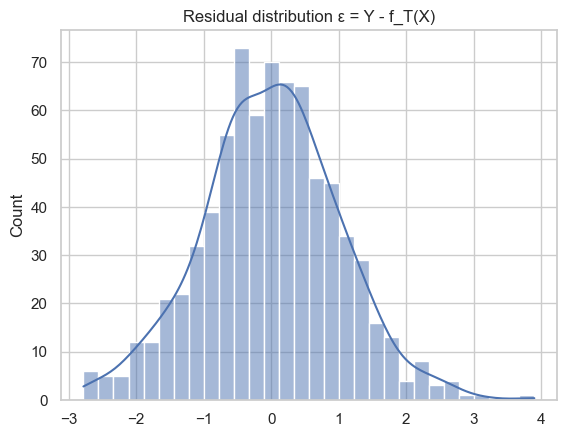

Residual mean: -0.005781775177527371
Residual std : 1.0101768070123156


In [23]:
sns.histplot(eps, bins=30, kde=True)
plt.title("Residual distribution ε = Y - f_T(X)")
plt.show()

print("Residual mean:", np.mean(eps))
print("Residual std :", np.std(eps))


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


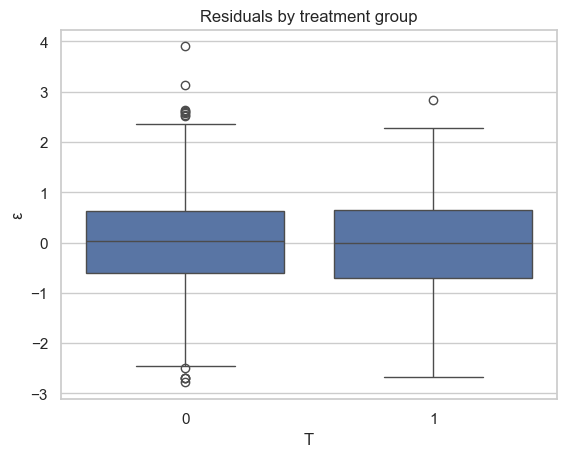

Mean ε | T=0: 0.00772841791794316
Mean ε | T=1: -0.0648767205159884


In [24]:
sns.boxplot(x=T, y=eps)
plt.title("Residuals by treatment group")
plt.xlabel("T")
plt.ylabel("ε")
plt.show()

print("Mean ε | T=0:", eps[T==0].mean())
print("Mean ε | T=1:", eps[T==1].mean())


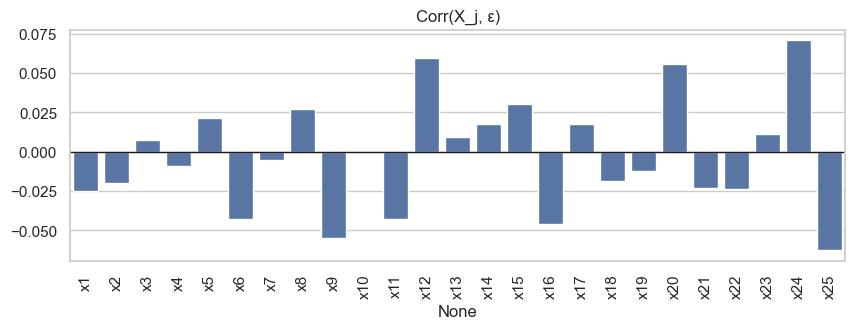

In [25]:
X_df = raw[[f"x{i}" for i in range(1, 26)]]
corrs = X_df.apply(lambda col: np.corrcoef(col, eps)[0,1])
plt.figure(figsize=(10,3))
sns.barplot(x=corrs.index, y=corrs.values)
plt.xticks(rotation=90)
plt.title("Corr(X_j, ε)")
plt.axhline(0, color='k', linewidth=1)
plt.show()


In [26]:
ate_true = np.mean(mu1 - mu0)
ate_struct = np.mean(mu1_hat - mu0_hat)
print("True ATE (oracle mu):      ", ate_true)
print("ATE from fitted functions: ", ate_struct)


True ATE (oracle mu):       4.016066896118338
ATE from fitted functions:  4.021848005427553


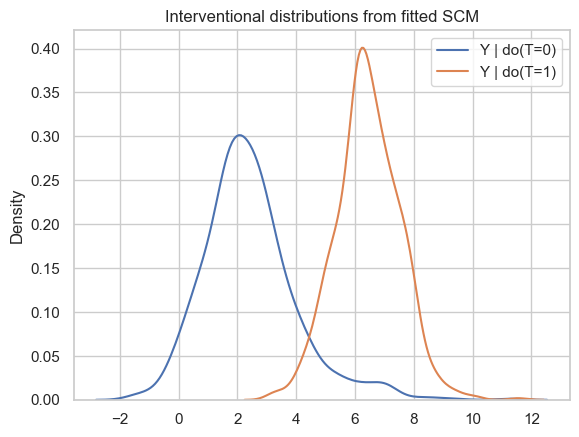

ATE from do-simulation: 4.021848005427553


In [27]:
Y_do0 = mu0_hat + eps  # reuse eps as exogenous noise
Y_do1 = mu1_hat + eps

sns.kdeplot(Y_do0, label="Y | do(T=0)")
sns.kdeplot(Y_do1, label="Y | do(T=1)")
plt.title("Interventional distributions from fitted SCM")
plt.legend()
plt.show()

print("ATE from do-simulation:", (Y_do1 - Y_do0).mean())
